# Curated coursework artifact

This is the complete final HW1 notebook. Local output directories, external Hateful Memes data/image caching, model-download handling, and raw-data exports have been removed. Displayed analytical figures and the final report preserve the archived evidence; nothing was rerun during curation.


## **SAVE A COPY OF THIS NOTEBOOK TO PUT ANSWERS INTO. SUBMIT A PDF THAT HAS THE WRITTEN ANSWERS WITH THIS COLAB**

(25 pts)

For our first homework assignment, we want you to perform the process of pre-preocessing data to use for training models. This is especially important in a multimodal setting, where you have several modalities that can be extracted from raw data.

Before we start directly processing data, let's think about a project objective or idea that you want to acheive with multimodal modeling/AI. This can range from anything, so be as creative as you want! Here are some questions to answer to help get you started:

1. What goal (or goals) do you want your model to do? An example would be predicting the genre of a movie, or analyzing sentiment from a video. We want you to think about and discuss what is the end goal of the project that you will end up implementing later in the course.
2. List out any datasets that you can find that can help accomplish this. Explain why you think the data is relevant and in addition discuss any drawbacks of the dataset.
3. What modalities do you choose to use? Why? Are there other modalities that could possibly be obtained that you don't plan on using? If so, why?
4. What difficulties did you encounter in obtaining the data?
5. Recall the [six core challenges of multimodal learning](https://arxiv.org/pdf/2209.03430). How do you plan on addressing them in your dataset or anticipate each of them impacting the way you design your dataset?




(20 pts)

We have provided a skeleton for you to start coding with, which contains an example of extracting frames of a video as images. Feel free to use this code as a starting point, but you are free to and encouraged to add more! The goal of this assignment (and what you will be graded on), is to extract a set of modalities from the dataset of your choice that is rich (in the sense that it would make sense to use/has valuable information) and contains unique information from other modalities.

**We strongly encourage that you take a good amount of time exploring and choosing the dataset you want to go with. The dataset/domain you decide to go with and the modalities you choose will be used for the rest of the HWs in this class. Create your dataset with this in mind!**

**You will submit a copy of this notebook with the code alongside your writeup. In your writeup, discuss the following:**


What difficulties did you encounter in extracting the modalities?  


In [2]:
import sys, os, subprocess

# Curation note: local project, data, and figure directories are omitted from the public static artifact.


In [3]:
import numpy as np
import scipy.sparse as sp
import networkx as nx
import pandas as pd
from collections import OrderedDict
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

# Container for MILP instances
class MILPInstance:
    def __init__(self, name, domain, A, b, c, var_types, constraint_senses, lb=None, ub=None):
        self.name = name
        self.domain = domain
        self.A = sp.csr_matrix(A) if not sp.issparse(A) else A.tocsr()
        self.b = np.asarray(b, dtype=float)
        self.c = np.asarray(c, dtype=float)
        self.var_types = list(var_types)
        self.constraint_senses = list(constraint_senses)
        self.m, self.n = self.A.shape
        self.lb = lb if lb is not None else np.zeros(self.n)
        self.ub = ub if ub is not None else np.ones(self.n) * np.inf

# --- Problem Generators ---
def generate_set_cover(instance_id, n_items=None, n_sets=None):
    n_items = n_items or np.random.randint(30, 80)
    n_sets  = n_sets  or np.random.randint(50, 150)
    rows, cols, data = [], [], []
    for j in range(n_sets):
        covered = np.random.choice(n_items, np.random.randint(1, max(2, n_items // 3)), replace=False)
        for i in covered:
            rows.append(i); cols.append(j); data.append(1.0)
    for i in range(n_items):
        if i not in rows:
            j = np.random.randint(0, n_sets)
            rows.append(i); cols.append(j); data.append(1.0)
    A = sp.csr_matrix((data, (rows, cols)), shape=(n_items, n_sets))
    return MILPInstance(f"setcover_{instance_id}", "Set Cover", A, np.ones(n_items),
                        np.random.uniform(1, 10, n_sets), ['B']*n_sets, ['>=']*n_items,
                        np.zeros(n_sets), np.ones(n_sets))

def generate_knapsack(instance_id, n_items=None):
    n_items = n_items or np.random.randint(40, 120)
    n_con = np.random.randint(3, 8)
    rows, cols, data = [], [], []
    for i in range(n_con):
        weights = np.random.uniform(1, 20, n_items)
        for j in range(n_items):
            rows.append(i); cols.append(j); data.append(weights[j])
    A = sp.csr_matrix((data, (rows, cols)), shape=(n_con, n_items))
    b = np.array([np.random.uniform(0.3, 0.6) * A[i, :].sum() for i in range(n_con)])
    return MILPInstance(f"knapsack_{instance_id}", "Knapsack", A, b,
                        np.random.uniform(1, 50, n_items), ['B']*n_items, ['<=']*n_con,
                        np.zeros(n_items), np.ones(n_items))

def generate_facility_location(instance_id, n_fac=None, n_cust=None):
    n_fac  = n_fac  or np.random.randint(10, 30)
    n_cust = n_cust or np.random.randint(20, 60)
    n_vars = n_fac + n_fac * n_cust
    rows, cols, data, senses = [], [], [], []
    for i in range(n_cust):
        for j in range(n_fac):
            rows.append(i); cols.append(n_fac + i * n_fac + j); data.append(1.0)
        senses.append('==')
    demands = np.random.uniform(1, 10, n_cust)
    caps = np.random.uniform(demands.sum()/n_fac*0.8, demands.sum()/n_fac*2.0, n_fac)
    for j in range(n_fac):
        row_idx = n_cust + j
        rows.append(row_idx); cols.append(j); data.append(-caps[j])
        for i in range(n_cust):
            rows.append(row_idx); cols.append(n_fac + i*n_fac + j); data.append(demands[i])
        senses.append('<=')
    m = n_cust + n_fac
    A = sp.csr_matrix((data, (rows, cols)), shape=(m, n_vars))
    b = np.concatenate([np.ones(n_cust), np.zeros(n_fac)])
    c = np.zeros(n_vars); c[:n_fac] = np.random.uniform(100,500,n_fac); c[n_fac:] = np.random.uniform(1,20,n_fac*n_cust)
    vt = ['B']*n_fac + ['C']*(n_fac*n_cust)
    return MILPInstance(f"facility_{instance_id}", "Facility Location", A, b, c, vt, senses,
                        np.zeros(n_vars), np.concatenate([np.ones(n_fac), np.ones(n_fac*n_cust)]))

def generate_independent_set(instance_id, n_nodes=None, edge_prob=None):
    n_nodes = n_nodes or np.random.randint(30, 80)
    edge_prob = edge_prob or np.random.uniform(0.1, 0.3)
    edges = [(i,j) for i in range(n_nodes) for j in range(i+1, n_nodes) if np.random.random() < edge_prob]
    if not edges: edges = [(0,1)]
    rows, cols, data = [], [], []
    for idx, (i,j) in enumerate(edges):
        rows.extend([idx, idx]); cols.extend([i, j]); data.extend([1.0, 1.0])
    A = sp.csr_matrix((data, (rows, cols)), shape=(len(edges), n_nodes))
    return MILPInstance(f"indset_{instance_id}", "Independent Set", A, np.ones(len(edges)),
                        -np.ones(n_nodes), ['B']*n_nodes, ['<=']*len(edges),
                        np.zeros(n_nodes), np.ones(n_nodes))

def generate_bin_packing(instance_id, n_items=None, n_bins=None):
    n_items = n_items or np.random.randint(20, 60)
    n_bins  = n_bins  or np.random.randint(10, 30)
    cap = np.random.uniform(80, 150)
    sizes = np.random.uniform(5, cap*0.4, n_items)
    n_vars = n_bins + n_items*n_bins
    rows, cols, data, senses = [], [], [], []
    for i in range(n_items):
        for j in range(n_bins):
            rows.append(i); cols.append(n_bins + i*n_bins + j); data.append(1.0)
        senses.append('==')
    for j in range(n_bins):
        rows.append(n_items+j); cols.append(j); data.append(-cap)
        for i in range(n_items):
            rows.append(n_items+j); cols.append(n_bins + i*n_bins + j); data.append(sizes[i])
        senses.append('<=')
    A = sp.csr_matrix((data, (rows, cols)), shape=(n_items+n_bins, n_vars))
    b = np.concatenate([np.ones(n_items), np.zeros(n_bins)])
    c = np.zeros(n_vars); c[:n_bins] = 1.0
    return MILPInstance(f"binpack_{instance_id}", "Bin Packing", A, b, c,
                        ['B']*n_vars, senses, np.zeros(n_vars), np.ones(n_vars))

def generate_combinatorial_auction(instance_id, n_items=None, n_bids=None):
    n_items = n_items or np.random.randint(20, 50)
    n_bids  = n_bids  or np.random.randint(40, 120)
    rows, cols, data, vals = [], [], [], []
    for j in range(n_bids):
        bundle = np.random.choice(n_items, np.random.randint(1, max(2, n_items//4)), replace=False)
        vals.append(np.random.uniform(1,10)*len(bundle))
        for i in bundle:
            rows.append(i); cols.append(j); data.append(1.0)
    A = sp.csr_matrix((data, (rows, cols)), shape=(n_items, n_bids))
    return MILPInstance(f"auction_{instance_id}", "Comb. Auction", A, np.ones(n_items),
                        -np.array(vals), ['B']*n_bids, ['<=']*n_items,
                        np.zeros(n_bids), np.ones(n_bids))

# --- Feature Extractors ---
def extract_symbolic_attributes(inst):
    A = inst.A; m, n = A.shape; nnz = A.nnz
    row_deg = np.diff(A.indptr)
    col_deg = np.diff(A.tocsc().indptr)
    nb = sum(1 for v in inst.var_types if v=='B')
    ni = sum(1 for v in inst.var_types if v=='I')
    nc = sum(1 for v in inst.var_types if v=='C')
    nl = sum(1 for s in inst.constraint_senses if s=='<=')
    ne = sum(1 for s in inst.constraint_senses if s=='==')
    ng = sum(1 for s in inst.constraint_senses if s=='>=')
    return OrderedDict({
        "m_constraints": m, "n_variables": n, "nnz": nnz,
        "density": nnz/max(m*n,1), "n_binary": nb, "n_integer": ni, "n_continuous": nc,
        "frac_binary": nb/max(n,1), "frac_continuous": nc/max(n,1),
        "n_leq": nl, "n_eq": ne, "n_geq": ng,
        "frac_leq": nl/max(m,1), "frac_eq": ne/max(m,1),
        "constraint_degree_mean": float(row_deg.mean()) if len(row_deg) else 0,
        "constraint_degree_max": float(row_deg.max()) if len(row_deg) else 0,
        "variable_degree_mean": float(col_deg.mean()) if len(col_deg) else 0,
        "variable_degree_max": float(col_deg.max()) if len(col_deg) else 0,
        "obj_coeff_mean": float(np.mean(np.abs(inst.c))),
        "obj_coeff_std": float(np.std(inst.c)),
        "rhs_mean": float(np.mean(inst.b)), "rhs_std": float(np.std(inst.b)),
    })

def extract_bipartite_graph(inst):
    G = nx.Graph()
    for i in range(inst.m):
        G.add_node(f"c_{i}", bipartite=0, node_type="constraint", sense=inst.constraint_senses[i])
    for j in range(inst.n):
        G.add_node(f"v_{j}", bipartite=1, node_type="variable", var_type=inst.var_types[j])
    A_coo = inst.A.tocoo()
    for i, j, val in zip(A_coo.row, A_coo.col, A_coo.data):
        G.add_edge(f"c_{i}", f"v_{j}", weight=val)
    return G

# --- Main Execution ---
generators = {
    "Set Cover": generate_set_cover, "Knapsack": generate_knapsack,
    "Facility Location": generate_facility_location, "Independent Set": generate_independent_set,
    "Bin Packing": generate_bin_packing, "Comb. Auction": generate_combinatorial_auction,
}
instances = []
for domain, gen_fn in generators.items():
    for i in range(30):
        instances.append(gen_fn(i))

records = []
for inst in instances:
    attrs = extract_symbolic_attributes(inst)
    attrs["name"] = inst.name; attrs["domain"] = inst.domain
    records.append(attrs)
df = pd.DataFrame(records)
feature_cols = [c for c in df.columns if c not in ("name", "domain")]

# Print Summary
print(f"{'Domain':<22} {'Count':>6} {'Avg m':>8} {'Avg n':>8} {'Avg nnz':>10} {'Avg density':>12}")
print("-" * 68)
for domain in df["domain"].unique():
    sub = df[df["domain"] == domain]
    print(f"{domain:<22} {len(sub):>6} {sub['m_constraints'].mean():>8.1f} "
          f"{sub['n_variables'].mean():>8.1f} {sub['nnz'].mean():>10.1f} "
          f"{sub['density'].mean():>12.4f}")

Domain                  Count    Avg m    Avg n    Avg nnz  Avg density
--------------------------------------------------------------------
Set Cover                  30     57.4     87.6      829.8       0.1650
Knapsack                   30      4.9     81.0      397.4       1.0000
Facility Location          30     54.0    652.6     1286.7       0.0377
Independent Set            30    327.5     56.4      655.1       0.0388
Bin Packing                30     62.0    893.4     1765.9       0.0336
Comb. Auction              30     35.8     85.3      360.6       0.1172


(15 pts)

As part of this assignment, we will look into visualizing you dataset in three parts:

1. Visualizing Data Distribution
2. Viualizing Samples
3. Visualizing Input Distribution

We have provided scripts that these visualizations using [t-SNE](https://en.wikipedia.org/wiki/T-distributed_stochastic_neighbor_embedding) (t-distributed stochastic neighbor embedding). Your goal is to use these to visualize each of these for your dataset and include the visualziations in your submission. You will likely need to adjust the hyperparameters for the tsne model.

**Modify the functions to try different ways to visualize the dataset. Use differenrt distributions, visualizations, etc. Be creative! In the write up, discuss what visualizations you tried, why, and submit what the visualizations looked like.**

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from matplotlib.lines import Line2D

# Data Distribution

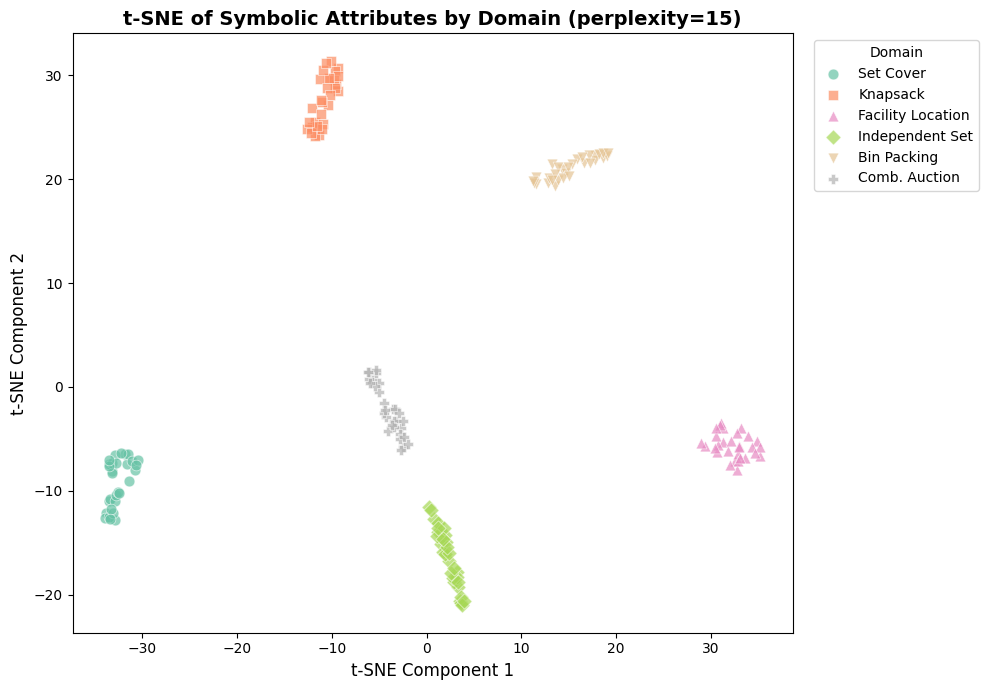

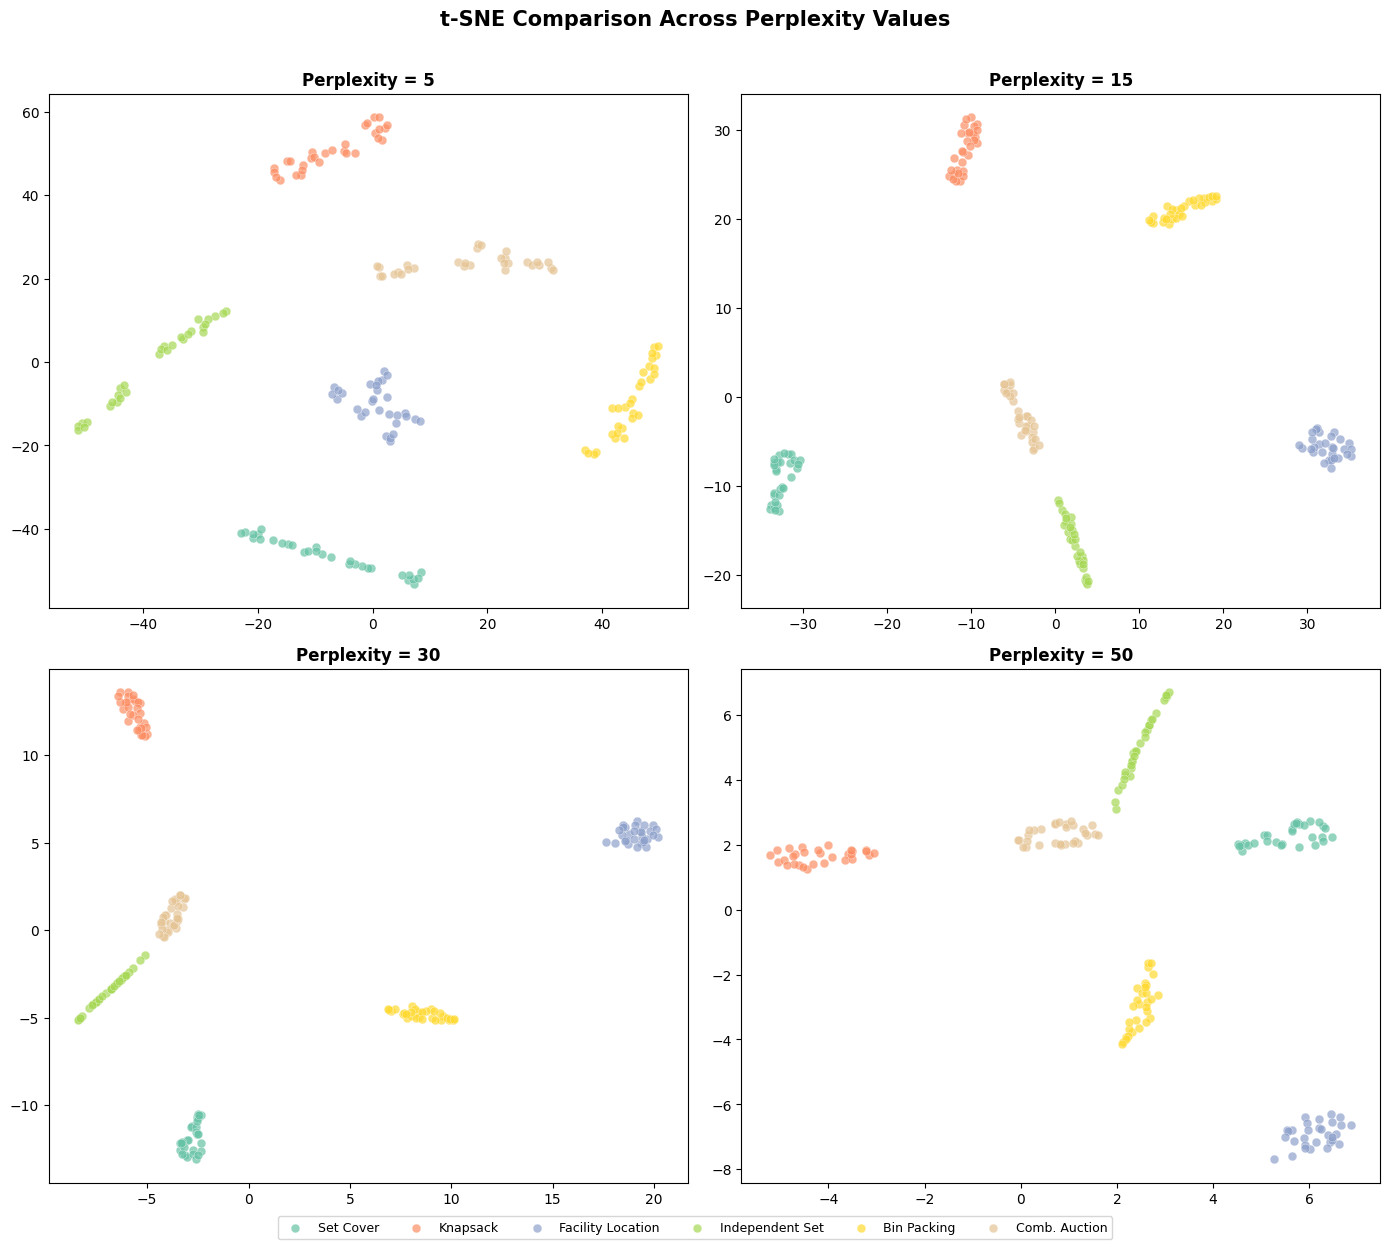

In [5]:
# ---- Figure 1: t-SNE of Symbolic Attributes by Domain ----
X = StandardScaler().fit_transform(df[feature_cols].values)
tsne = TSNE(n_components=2, perplexity=15, max_iter=1000, random_state=42, learning_rate='auto', init='pca')
X_tsne = tsne.fit_transform(X)

fig, ax = plt.subplots(figsize=(10, 7))
domains = df["domain"].unique()
colors = plt.cm.Set2(np.linspace(0, 1, len(domains)))
markers = ['o', 's', '^', 'D', 'v', 'P']
for idx, domain in enumerate(domains):
    mask = df["domain"] == domain
    ax.scatter(X_tsne[mask.values, 0], X_tsne[mask.values, 1], c=[colors[idx]],
               label=domain, marker=markers[idx % len(markers)], s=60, alpha=0.7,
               edgecolors='white', linewidth=0.5)
ax.set_xlabel("t-SNE Component 1", fontsize=12); ax.set_ylabel("t-SNE Component 2", fontsize=12)
ax.set_title("t-SNE of Symbolic Attributes by Domain (perplexity=15)", fontsize=14, fontweight='bold')
ax.legend(title="Domain", fontsize=10, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

# ---- Figure 2: t-SNE Perplexity Comparison ----
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
colors_map = {d: plt.cm.Set2(i / len(domains)) for i, d in enumerate(domains)}
for ax, perp in zip(axes.flat, [5, 15, 30, 50]):
    X_t = TSNE(n_components=2, perplexity=perp, max_iter=1000, random_state=42,
               learning_rate='auto', init='pca').fit_transform(X)
    for domain in domains:
        mask = df["domain"] == domain
        ax.scatter(X_t[mask.values, 0], X_t[mask.values, 1], c=[colors_map[domain]],
                   label=domain, s=40, alpha=0.7, edgecolors='white', linewidth=0.3)
    ax.set_title(f"Perplexity = {perp}", fontsize=12, fontweight='bold')
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("t-SNE Comparison Across Perplexity Values", fontsize=15, fontweight='bold', y=1.01)
plt.show()



# Samples

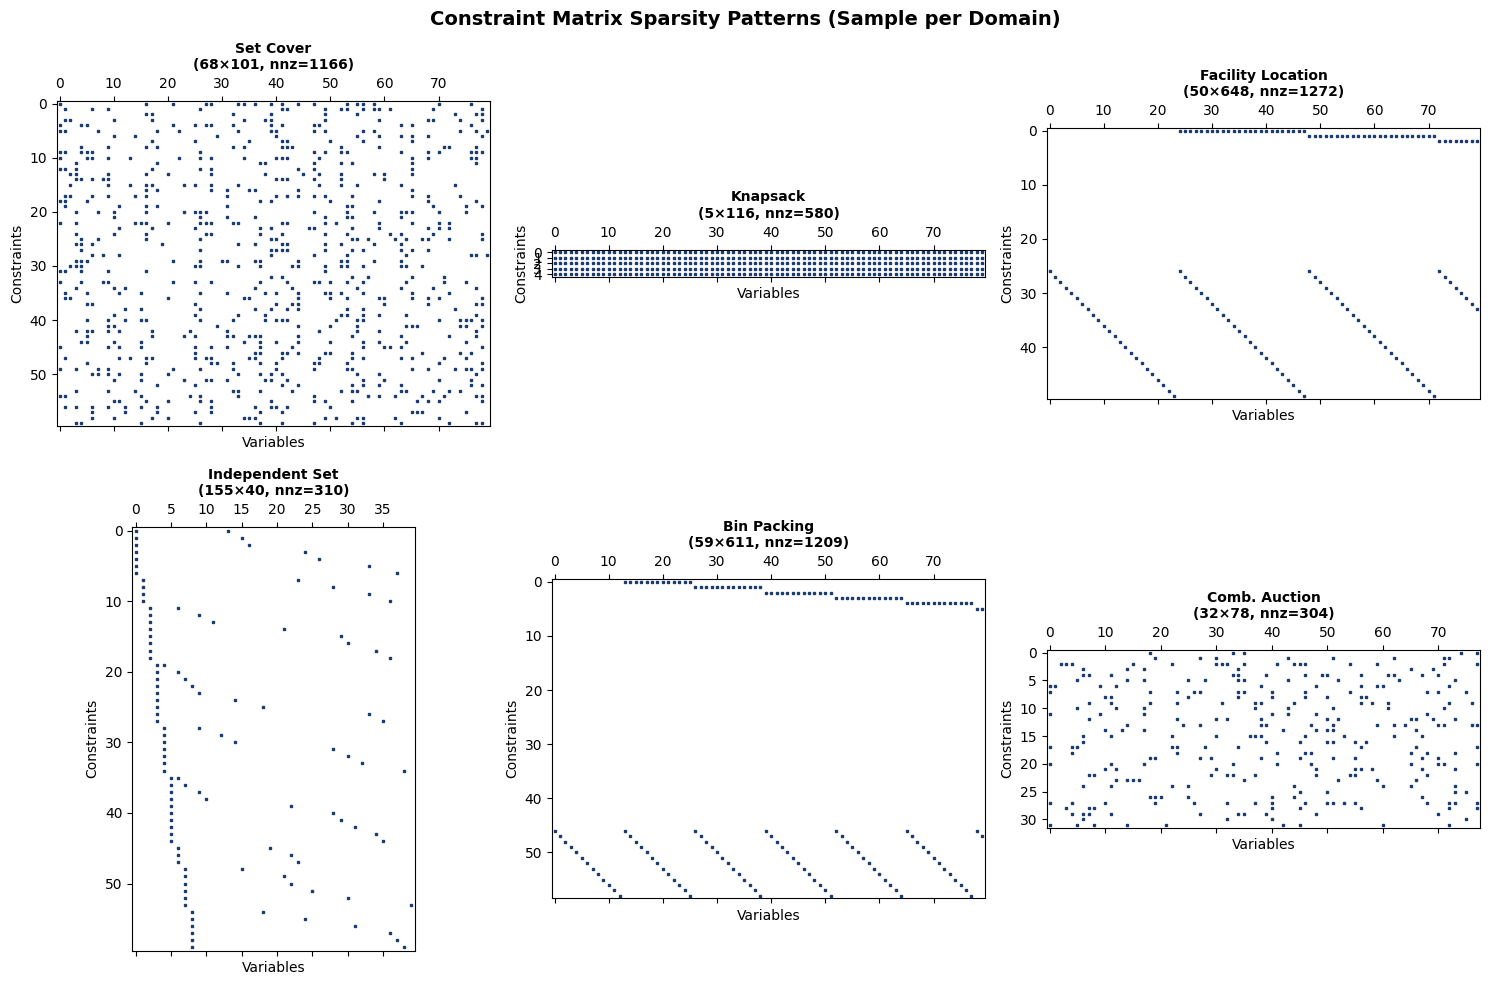

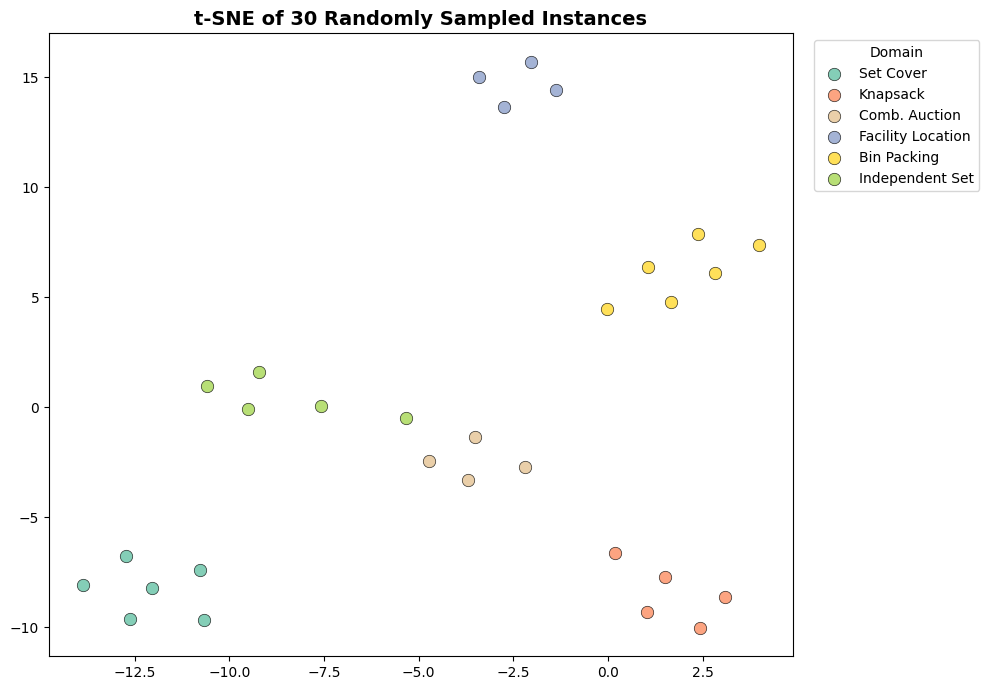

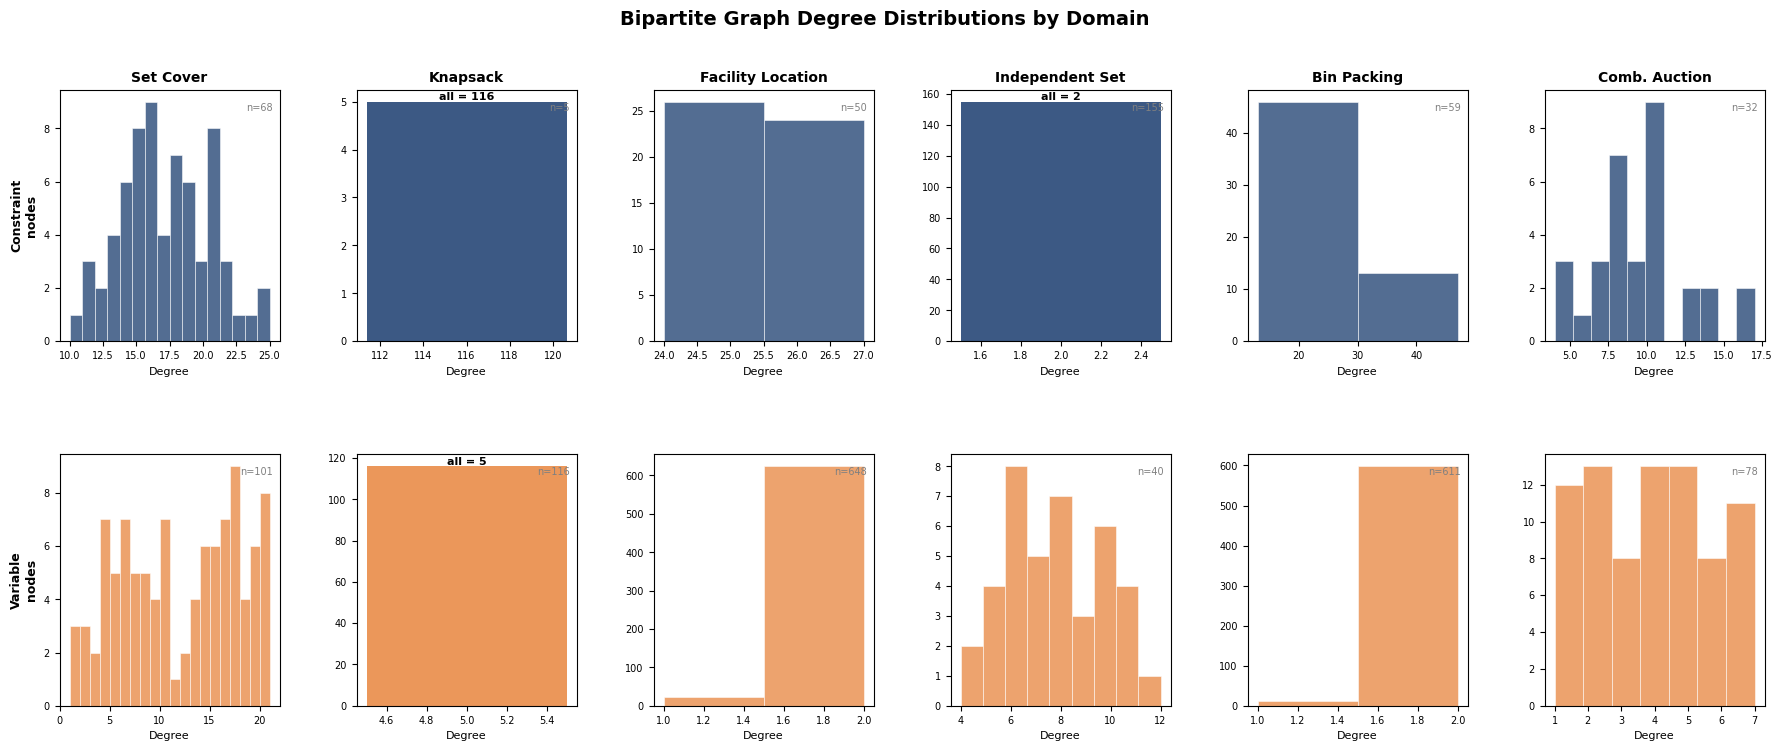

In [6]:
# ---- Figure 3: Sparsity Patterns ----
seen, samples = {}, []
for inst in instances:
    if inst.domain not in seen:
        seen[inst.domain] = True; samples.append(inst)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, inst in zip(axes.flat, samples[:6]):
    A_d = inst.A[:min(60, inst.m), :min(80, inst.n)].toarray()
    ax.spy(A_d, markersize=1.5, color='#1A3C6E')
    ax.set_title(f"{inst.domain}\n({inst.m}×{inst.n}, nnz={inst.A.nnz})", fontsize=10, fontweight='bold')
    ax.set_xlabel("Variables"); ax.set_ylabel("Constraints")
fig.suptitle("Constraint Matrix Sparsity Patterns (Sample per Domain)", fontsize=14, fontweight='bold')
plt.show()

# ---- Figure 5: Sample t-SNE (30 random samples) ----
sampled_df = df.sample(n=30, random_state=42)
X_s = StandardScaler().fit_transform(sampled_df[feature_cols].values)
X_st = TSNE(n_components=2, perplexity=8, max_iter=1000, random_state=42, learning_rate='auto', init='pca').fit_transform(X_s)
fig, ax = plt.subplots(figsize=(10, 7))
for domain in sampled_df["domain"].unique():
    mask = sampled_df["domain"] == domain
    ax.scatter(X_st[mask.values, 0], X_st[mask.values, 1], c=[colors_map[domain]],
               label=domain, s=80, alpha=0.8, edgecolors='black', linewidth=0.5)
ax.set_title("t-SNE of 30 Randomly Sampled Instances", fontsize=14, fontweight='bold')
ax.legend(title="Domain", fontsize=10, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

# ---- Figure 6: Degree Distributions (improved) ----
fig, axes = plt.subplots(2, 6, figsize=(22, 8), gridspec_kw={"hspace": 0.45, "wspace": 0.35})
for col, inst in enumerate(samples[:6]):
    G = extract_bipartite_graph(inst)
    c_nodes = [n for n, d in G.nodes(data=True) if d.get("node_type") == "constraint"]
    v_nodes = [n for n, d in G.nodes(data=True) if d.get("node_type") == "variable"]
    c_deg = np.array([G.degree(n) for n in c_nodes])
    v_deg = np.array([G.degree(n) for n in v_nodes])
    for row, deg, color, label in [(0, c_deg, '#1A3C6E', 'Constraint'), (1, v_deg, '#E8853D', 'Variable')]:
        ax = axes[row, col]
        if len(set(deg)) == 1:
            ax.bar([deg[0]], [len(deg)], color=color, width=max(1, deg[0]*0.08), alpha=0.85)
            ax.annotate(f"all = {deg[0]}", xy=(deg[0], len(deg)), ha='center', va='bottom', fontsize=8, fontweight='bold')
        else:
            ax.hist(deg, bins=min(20, len(set(deg))), color=color, alpha=0.75, edgecolor='white', linewidth=0.5)
        ax.set_xlabel("Degree", fontsize=8); ax.tick_params(labelsize=7)
        ax.text(0.97, 0.95, f"n={len(deg)}", transform=ax.transAxes, fontsize=7, ha='right', va='top', color='gray')
        if col == 0: ax.set_ylabel(f"{label}\nnodes", fontsize=9, fontweight='bold')
        if row == 0: ax.set_title(inst.domain, fontsize=10, fontweight='bold')
fig.suptitle("Bipartite Graph Degree Distributions by Domain", fontsize=14, fontweight='bold')
plt.show()



# Input Distribution

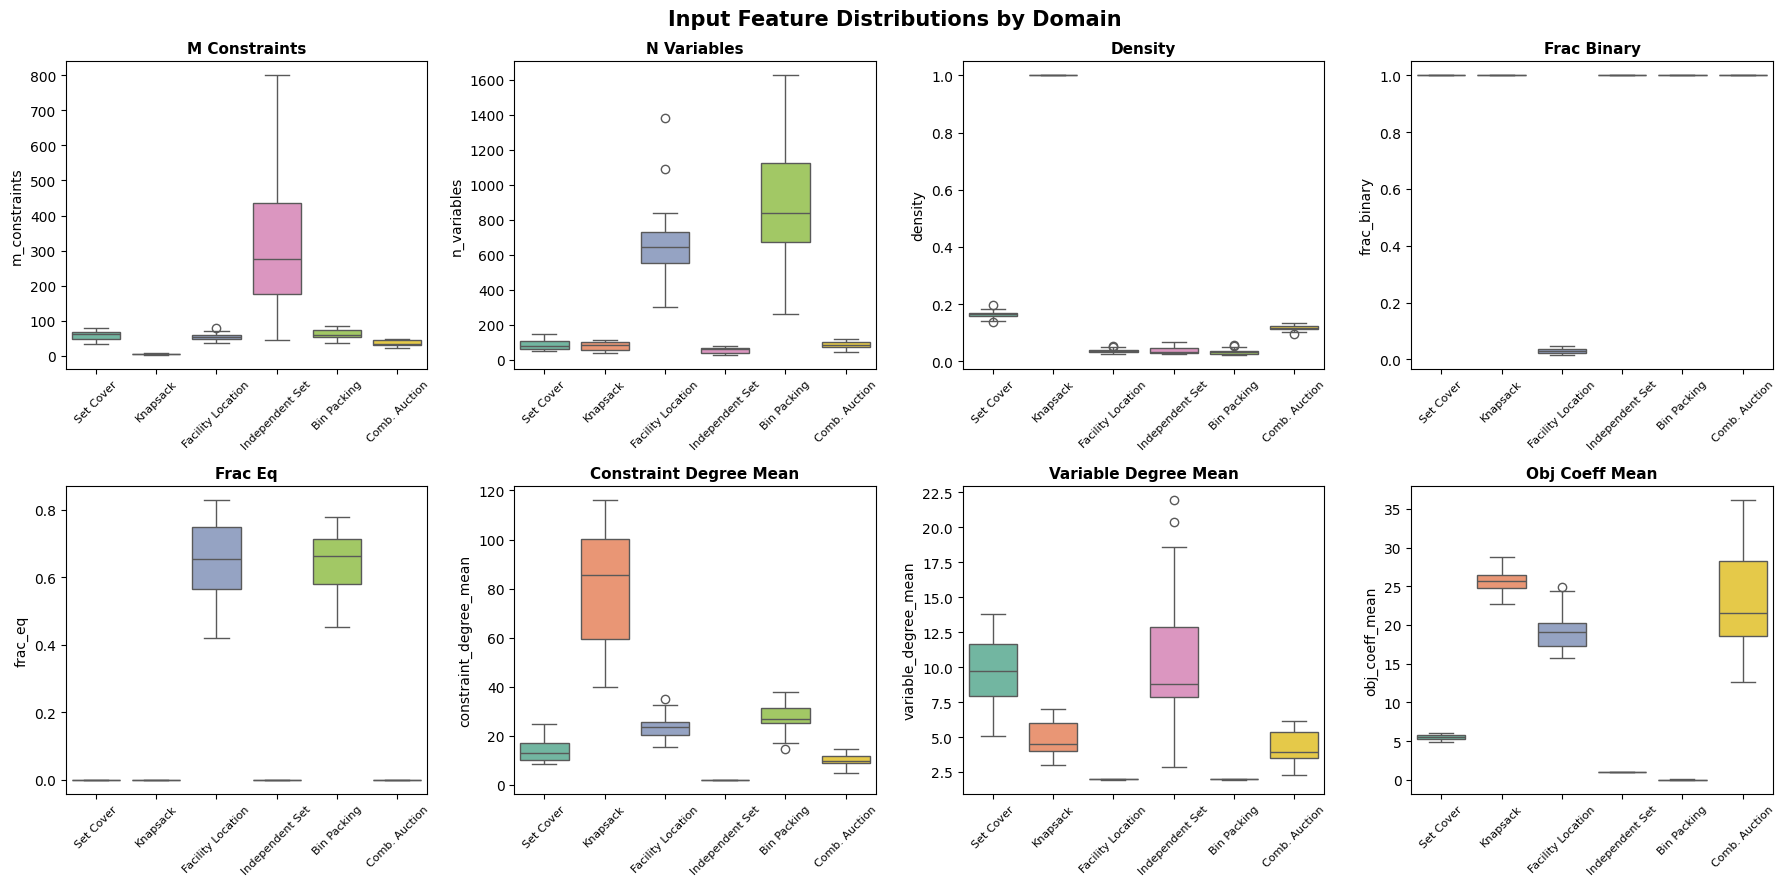

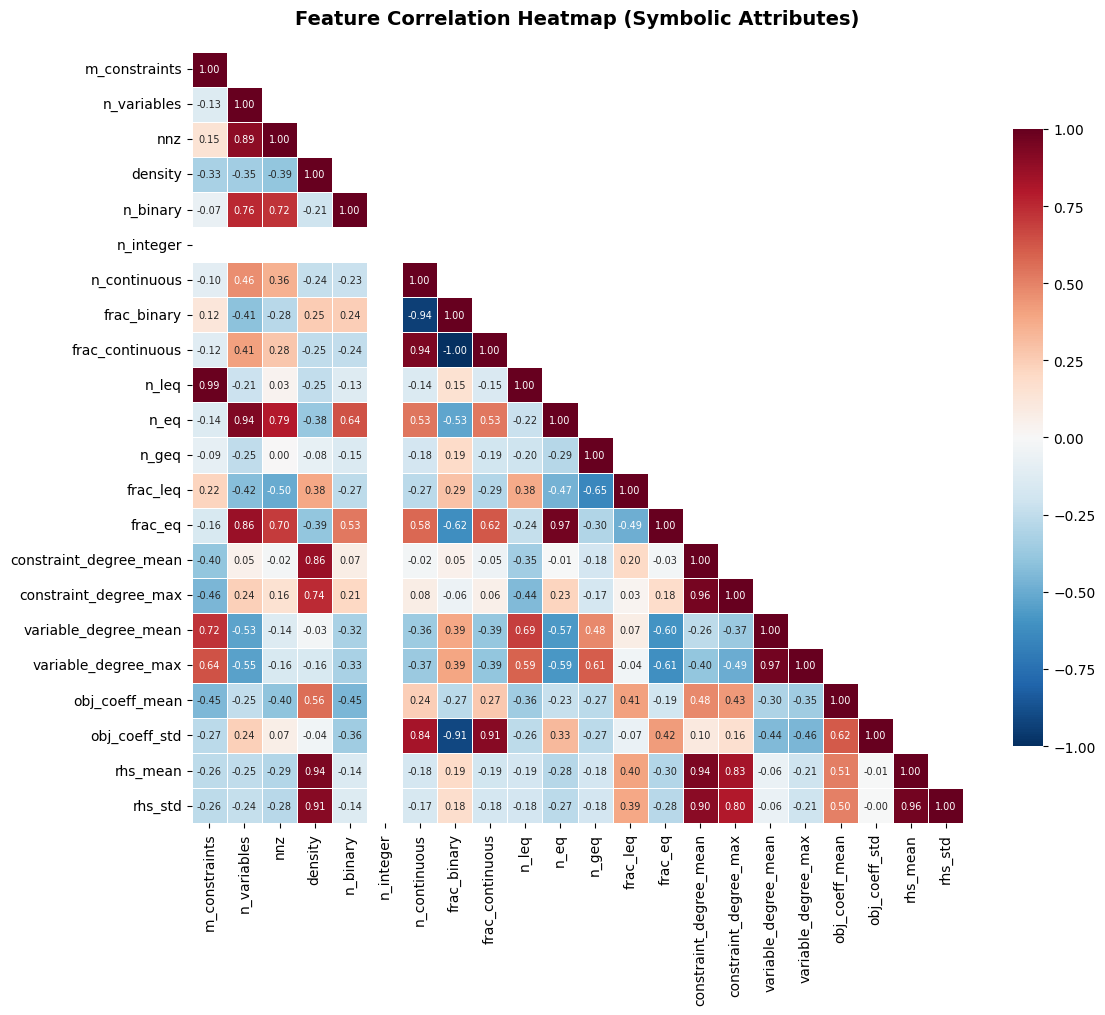

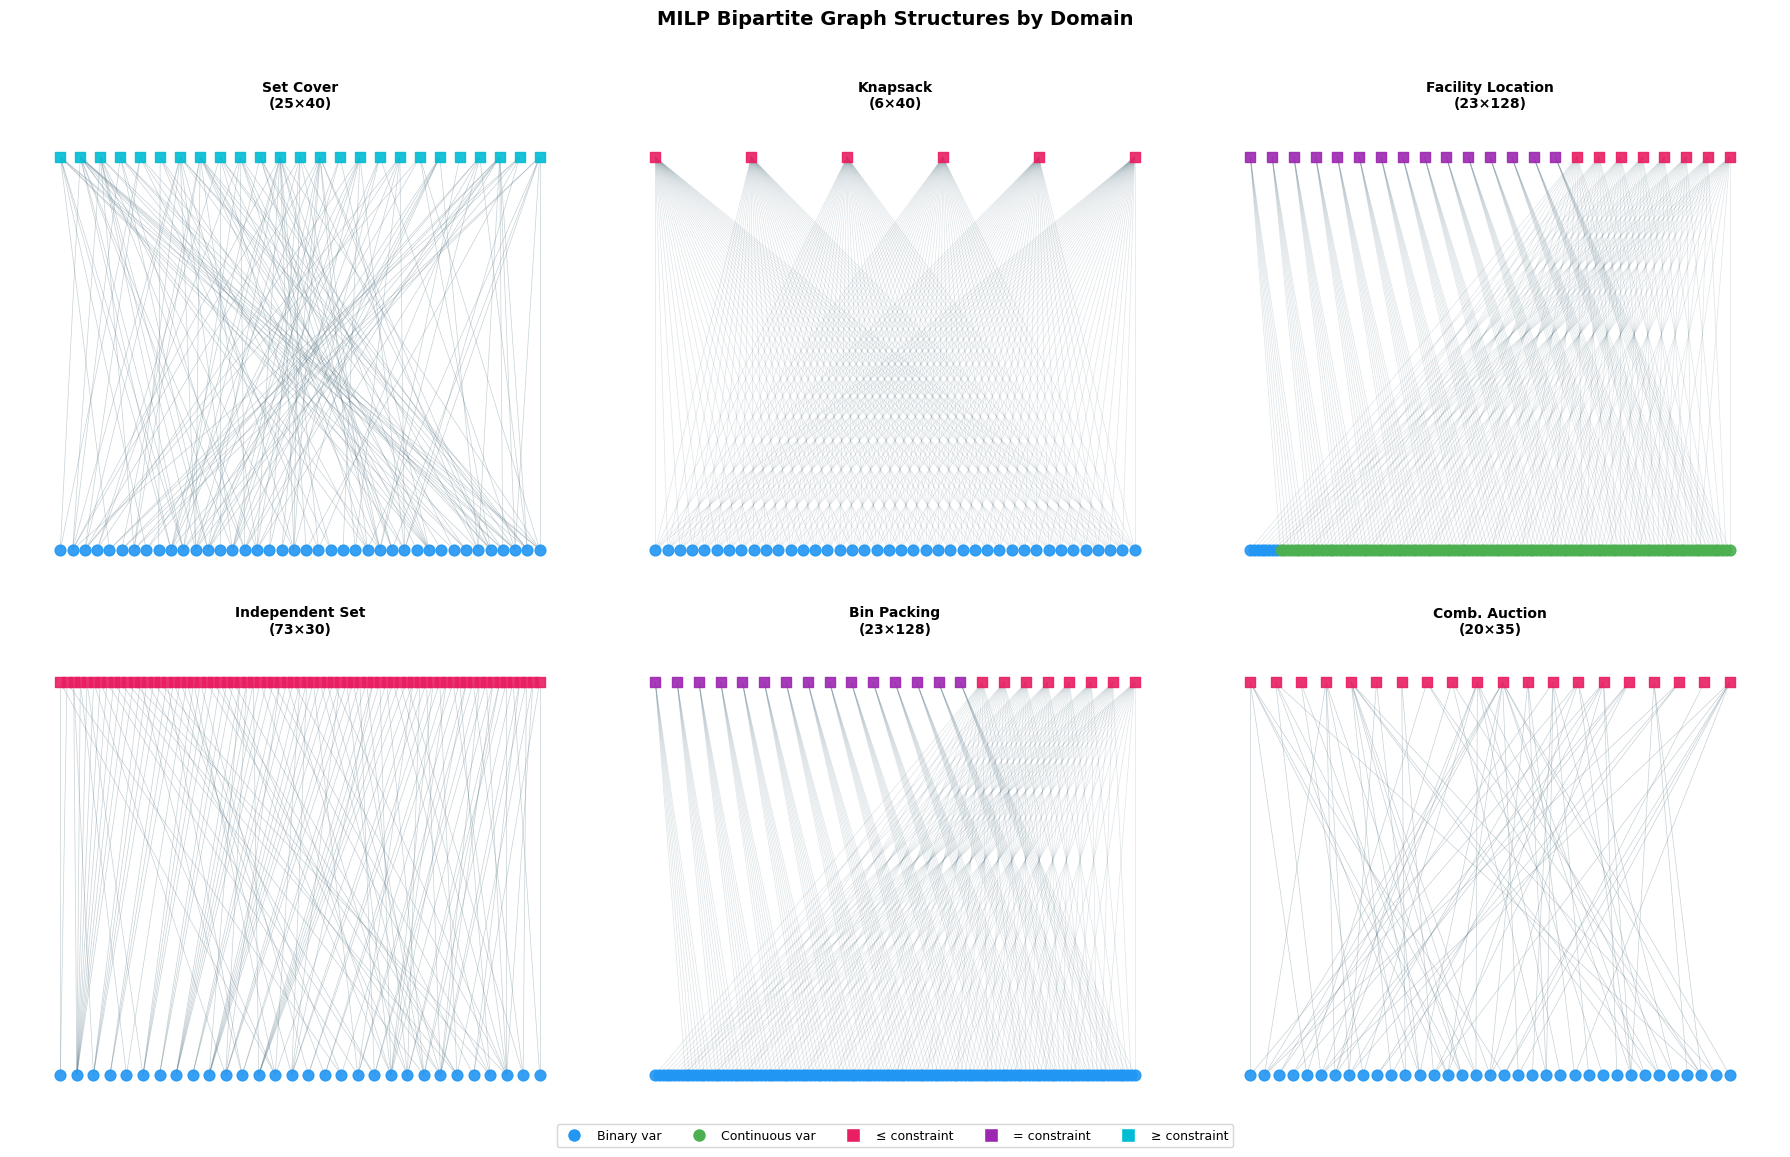

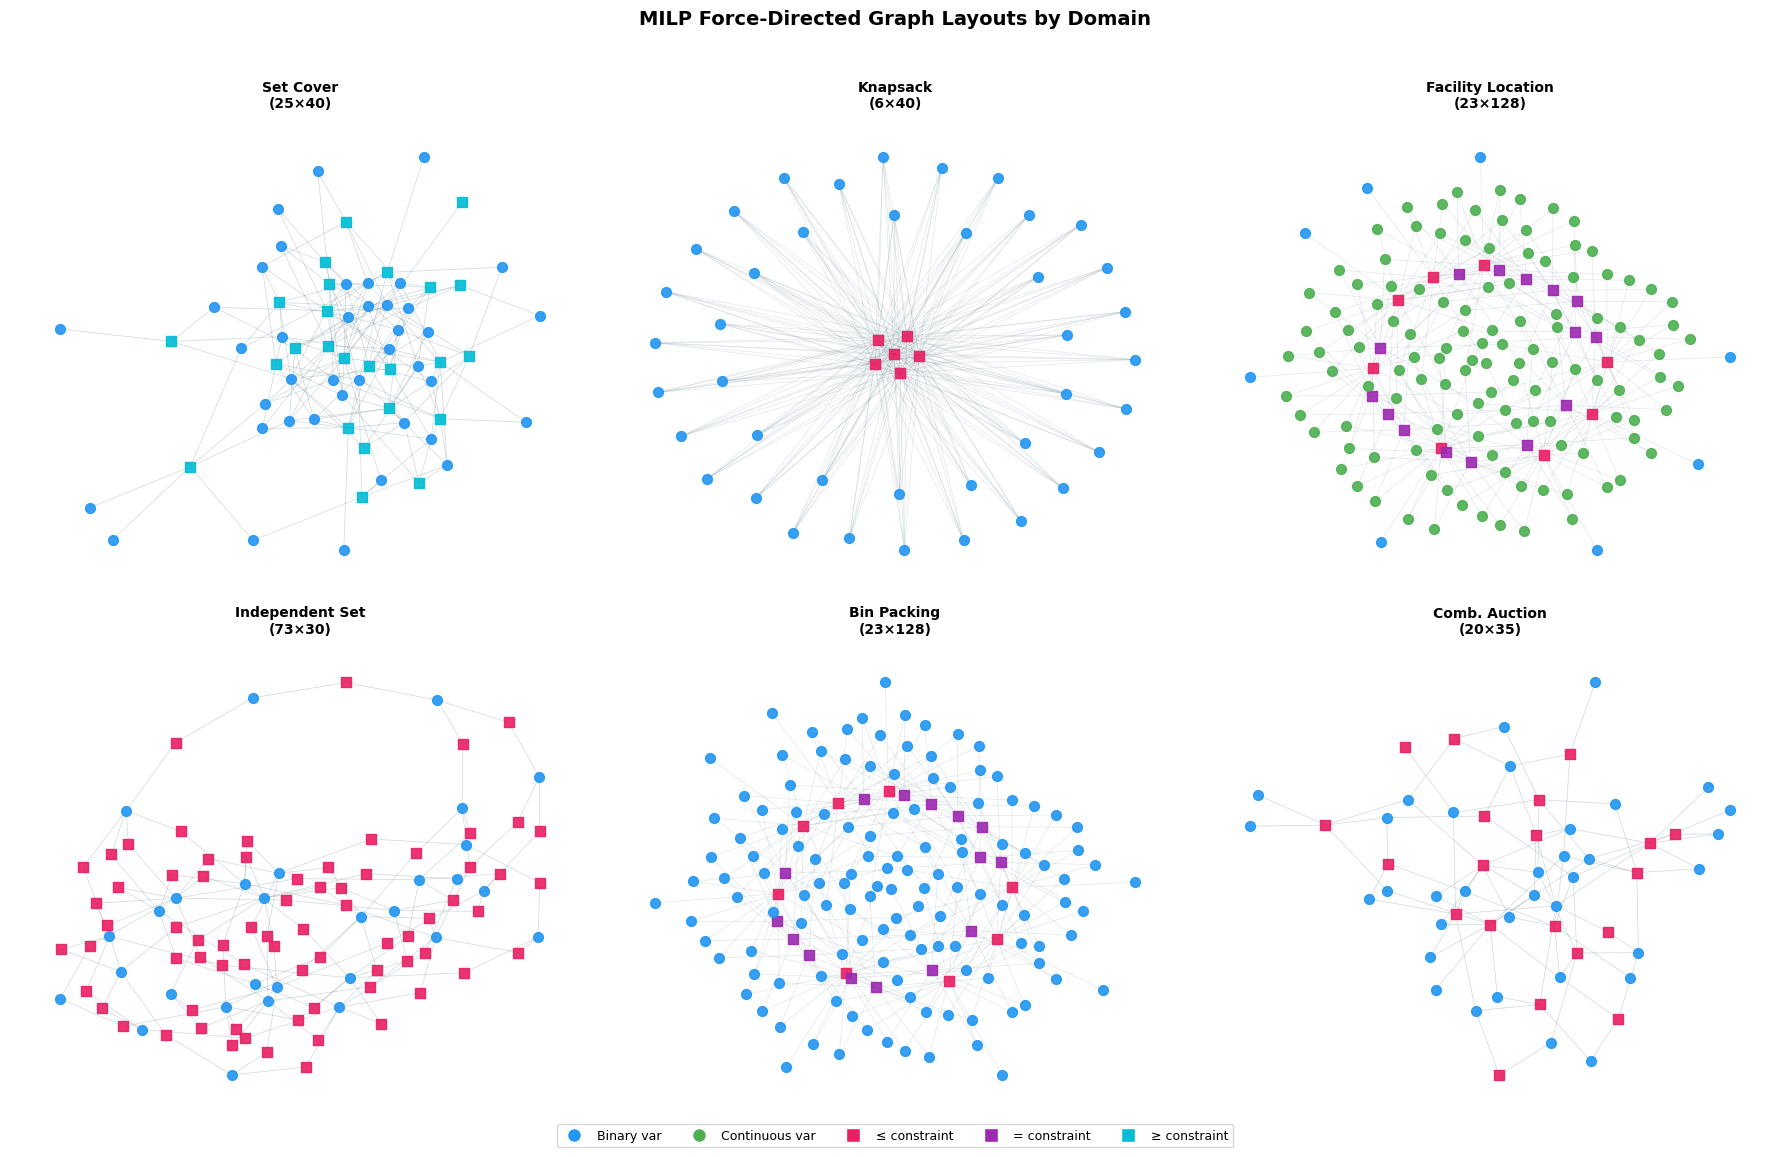

In [12]:
# ---- Figure 4: Input Feature Distributions ----
key_features = ["m_constraints", "n_variables", "density", "frac_binary",
                "frac_eq", "constraint_degree_mean", "variable_degree_mean", "obj_coeff_mean"]
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, feat in zip(axes.flat, key_features):
    sns.boxplot(data=df, x="domain", y=feat, ax=ax, palette="Set2", hue="domain", legend=False)
    ax.set_title(feat.replace("_", " ").title(), fontsize=11, fontweight='bold')
    ax.set_xlabel(""); ax.tick_params(axis='x', rotation=45, labelsize=8)
fig.suptitle("Input Feature Distributions by Domain", fontsize=15, fontweight='bold')
plt.show()

# ---- Figure 7: Correlation Heatmap ----
corr = df[feature_cols].corr()
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            square=True, linewidths=0.5, annot_kws={"size": 7}, cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Heatmap (Symbolic Attributes)", fontsize=14, fontweight='bold', pad=20)
plt.show()

# ---- Figure 8 & 9: Bipartite & Spring Graph Layouts ----
VAR_COLORS = {"B": "#2196F3", "I": "#FF9800", "C": "#4CAF50"}
SENSE_COLORS = {"<=": "#E91E63", "==": "#9C27B0", ">=": "#00BCD4"}

small_generators = [
    ("Set Cover",         lambda: generate_set_cover(99, n_items=25, n_sets=40)),
    ("Knapsack",          lambda: generate_knapsack(99, n_items=40)),
    ("Facility Location", lambda: generate_facility_location(99, n_fac=8, n_cust=15)),
    ("Independent Set",   lambda: generate_independent_set(99, n_nodes=30, edge_prob=0.15)),
    ("Bin Packing",       lambda: generate_bin_packing(99, n_items=15, n_bins=8)),
    ("Comb. Auction",     lambda: generate_combinatorial_auction(99, n_items=20, n_bids=35)),
]
small_instances = [gen() for _, gen in small_generators]

def draw_bipartite(inst, ax, max_v=128, max_c=128):
    nv, nc = min(inst.n, max_v), min(inst.m, max_c)
    A_sub = inst.A[:nc, :nv]; G = nx.Graph()
    for j in range(nv): G.add_node(f"v{j}", ntype="var", vtype=inst.var_types[j] if j<len(inst.var_types) else "C")
    for i in range(nc): G.add_node(f"c{i}", ntype="con", sense=inst.constraint_senses[i] if i<len(inst.constraint_senses) else "<=")
    for r, c, v in zip(*sp.find(A_sub)): G.add_edge(f"c{r}", f"v{c}")
    pos = {f"c{i}": (i/max(nc-1,1), 1.0) for i in range(nc)}
    pos.update({f"v{j}": (j/max(nv-1,1), 0.0) for j in range(nv)})
    ne = G.number_of_edges(); ea = 0.6 if ne<50 else (0.35 if ne<200 else (0.2 if ne<500 else 0.12))
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=ea, edge_color='#607D8B', width=0.5)
    for sense, col in SENSE_COLORS.items():
        nodes = [n for n in G if G.nodes[n].get("ntype")=="con" and G.nodes[n].get("sense")==sense]
        if nodes: nx.draw_networkx_nodes(G, pos, nodelist=nodes, ax=ax, node_color=col, node_shape='s', node_size=60, alpha=0.9)
    for vt, col in VAR_COLORS.items():
        nodes = [n for n in G if G.nodes[n].get("ntype")=="var" and G.nodes[n].get("vtype")==vt]
        if nodes: nx.draw_networkx_nodes(G, pos, nodelist=nodes, ax=ax, node_color=col, node_shape='o', node_size=60, alpha=0.9)
    ax.set_title(f"{inst.domain}\n({inst.m}×{inst.n})", fontsize=10, fontweight='bold'); ax.axis('off')

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for ax, inst in zip(axes.flat, small_instances): draw_bipartite(inst, ax)
legend_el = [Line2D([0],[0],marker='o',color='w',markerfacecolor=VAR_COLORS['B'],markersize=10,label='Binary var'),
             Line2D([0],[0],marker='o',color='w',markerfacecolor=VAR_COLORS['C'],markersize=10,label='Continuous var'),
             Line2D([0],[0],marker='s',color='w',markerfacecolor=SENSE_COLORS['<='],markersize=10,label='≤ constraint'),
             Line2D([0],[0],marker='s',color='w',markerfacecolor=SENSE_COLORS['=='],markersize=10,label='= constraint'),
             Line2D([0],[0],marker='s',color='w',markerfacecolor=SENSE_COLORS['>='],markersize=10,label='≥ constraint')]
fig.legend(handles=legend_el, loc='lower center', ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("MILP Bipartite Graph Structures by Domain", fontsize=14, fontweight='bold', y=1.02)
plt.show()

# ---- Figure 9: Spring Layout ----
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for ax, inst in zip(axes.flat, small_instances):
    nv, nc = min(inst.n, 128), min(inst.m, 128); A_sub = inst.A[:nc, :nv]; G = nx.Graph()
    for j in range(nv): G.add_node(f"v{j}", ntype="var", vtype=inst.var_types[j] if j<len(inst.var_types) else "C")
    for i in range(nc): G.add_node(f"c{i}", ntype="con", sense=inst.constraint_senses[i] if i<len(inst.constraint_senses) else "<=")
    for r, c, v in zip(*sp.find(A_sub)): G.add_edge(f"c{r}", f"v{c}")
    pos = nx.spring_layout(G, seed=42, k=1.8/np.sqrt(max(G.number_of_nodes(),1)), iterations=80)
    ne = G.number_of_edges(); ea = 0.5 if ne<50 else (0.3 if ne<200 else (0.18 if ne<500 else 0.1))
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=ea, edge_color='#607D8B', width=0.5)
    for sense, col in SENSE_COLORS.items():
        nodes = [n for n in G if G.nodes[n].get("ntype")=="con" and G.nodes[n].get("sense")==sense]
        if nodes: nx.draw_networkx_nodes(G, pos, nodelist=nodes, ax=ax, node_color=col, node_shape='s', node_size=50, alpha=0.9)
    for vt, col in VAR_COLORS.items():
        nodes = [n for n in G if G.nodes[n].get("ntype")=="var" and G.nodes[n].get("vtype")==vt]
        if nodes: nx.draw_networkx_nodes(G, pos, nodelist=nodes, ax=ax, node_color=col, node_shape='o', node_size=50, alpha=0.9)
    ax.set_title(f"{inst.domain}\n({inst.m}×{inst.n})", fontsize=10, fontweight='bold'); ax.axis('off')
fig.legend(handles=legend_el, loc='lower center', ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("MILP Force-Directed Graph Layouts by Domain", fontsize=14, fontweight='bold', y=1.02)
plt.show()


(20 pts)

Now let's consider what evaluation metrics you would want to use in training and validation. Answer the following:

1. What evalution metrics are you planning on using? Why?
2. Are there any other metrics that could be used here or that you considered?
3. List out the pros and cons of the evaluation metrics you decided to go with.

In addition, code up functions that calculate the metric. We have provided a template to start with. This will be used later for when we do start training models, so take some time in designing this!

In [8]:
import numpy as np
from collections import Counter

# ============================================================
# Part 4 — Evaluation Metrics
# ============================================================

# ------------------------------------------------------------------
# Accuracy
# ------------------------------------------------------------------
def accuracy(predictions, ground_truths):
    """Calculates fraction of correct predictions."""
    if len(ground_truths) == 0:
        raise ValueError("No ground truths provided")
    num_correct = sum(p == t for p, t in zip(predictions, ground_truths))
    return num_correct / len(ground_truths)

# ------------------------------------------------------------------
# AUROC
# ------------------------------------------------------------------
def auroc(scores, labels):
    """
    Computes AUROC from continuous scores and binary labels.
    Returns float in [0, 1].
    """
    scores = np.asarray(scores, dtype=float)
    labels = np.asarray(labels, dtype=int)
    
    if len(scores) != len(labels):
        raise ValueError("Length mismatch between scores and labels")
    if set(labels.tolist()) != {0, 1}:
        raise ValueError("Labels must be binary (0, 1)")
    
    # Sort descending
    order = np.argsort(-scores)
    labels_sorted = labels[order]
    
    n_pos = labels.sum()
    n_neg = len(labels) - n_pos
    
    if n_pos == 0 or n_neg == 0:
        raise ValueError("Data must contain both positive and negative samples")
    
    # Build ROC
    tpr_list, fpr_list = [0.0], [0.0]
    tp, fp = 0, 0
    for lab in labels_sorted:
        if lab == 1:
            tp += 1
        else:
            fp += 1
        tpr_list.append(tp / n_pos)
        fpr_list.append(fp / n_neg)
    
    # Trapezoidal integration
    auc = 0.0
    for i in range(1, len(fpr_list)):
        auc += (fpr_list[i] - fpr_list[i - 1]) * (tpr_list[i] + tpr_list[i - 1]) / 2
    return auc

# ------------------------------------------------------------------
# F1 Score (Macro)
# ------------------------------------------------------------------
def f1_score_macro(predictions, ground_truths):
    """Computes macro-averaged F1 score for multi-class data."""
    predictions = list(predictions)
    ground_truths = list(ground_truths)
    
    if len(predictions) != len(ground_truths):
        raise ValueError("Length mismatch")
    if not ground_truths:
        raise ValueError("No ground truths provided")
    
    classes = sorted(set(ground_truths) | set(predictions))
    f1_per_class = []
    
    for cls in classes:
        tp = sum(1 for p, t in zip(predictions, ground_truths) if p == cls and t == cls)
        fp = sum(1 for p, t in zip(predictions, ground_truths) if p == cls and t != cls)
        fn = sum(1 for p, t in zip(predictions, ground_truths) if p != cls and t == cls)
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        
        if precision + recall > 0:
            f1 = 2 * precision * recall / (precision + recall)
        else:
            f1 = 0.0
        f1_per_class.append(f1)
    
    return sum(f1_per_class) / len(f1_per_class)

# ------------------------------------------------------------------
# Top-k Accuracy
# ------------------------------------------------------------------
def topk_accuracy(score_matrix, ground_truths, k=3):
    """
    Computes top-k accuracy.
    score_matrix: (n_samples, n_classes)
    ground_truths: (n_samples,) indices
    """
    score_matrix = np.asarray(score_matrix, dtype=float)
    ground_truths = np.asarray(ground_truths, dtype=int)
    
    if score_matrix.shape[0] != len(ground_truths):
        raise ValueError("Rows in score_matrix must match length of ground_truths")
    
    n_samples = len(ground_truths)
    correct = 0
    for i in range(n_samples):
        topk_indices = np.argsort(-score_matrix[i])[:k]
        if ground_truths[i] in topk_indices:
            correct += 1
    return correct / n_samples

# ------------------------------------------------------------------
# Cosine Similarity Gap
# ------------------------------------------------------------------
def cosine_similarity_gap(embeddings_a, embeddings_b, labels):
    """
    Computes mean cosine similarity for matched vs. mismatched pairs.
    labels: 1 (matched), 0 (mismatched)
    """
    a = np.asarray(embeddings_a, dtype=float)
    b = np.asarray(embeddings_b, dtype=float)
    labels = np.asarray(labels, dtype=int)
    
    dot = np.sum(a * b, axis=1)
    norm_a = np.linalg.norm(a, axis=1) + 1e-12
    norm_b = np.linalg.norm(b, axis=1) + 1e-12
    cos_sim = dot / (norm_a * norm_b)
    
    matched_mask    = labels == 1
    mismatched_mask = labels == 0
    
    mean_matched    = cos_sim[matched_mask].mean() if matched_mask.any() else 0.0
    mean_mismatched = cos_sim[mismatched_mask].mean() if mismatched_mask.any() else 0.0
    
    return {
        "mean_matched":    round(float(mean_matched), 4),
        "mean_mismatched": round(float(mean_mismatched), 4),
        "gap":             round(float(mean_matched - mean_mismatched), 4),
    }

# ==================================================================
# Metric Verification / Synthetic Test
# ==================================================================
if __name__ == "__main__":
    np.random.seed(42)

    # 1. Accuracy
    preds_binary = [1, 0, 1, 1, 0, 0, 1, 0]
    truth_binary = [1, 0, 1, 0, 0, 0, 1, 1]
    print(f"Accuracy: {accuracy(preds_binary, truth_binary):.4f}")

    # 2. AUROC
    scores_pos = np.random.normal(loc=0.7, scale=0.15, size=50).clip(0, 1)
    scores_neg = np.random.normal(loc=0.3, scale=0.15, size=50).clip(0, 1)
    all_scores = np.concatenate([scores_pos, scores_neg])
    all_labels = np.array([1]*50 + [0]*50)
    print(f"AUROC:    {auroc(all_scores, all_labels):.4f}")

    # 3. F1 Macro
    classes = ["SetCover", "Knapsack", "FacilityLoc", "IndepSet", "BinPack", "CombAuction"]
    truth_multi = []
    preds_multi = []
    for cls in classes:
        truth_multi.extend([cls] * 30)
        # Simulate 75% accuracy
        preds_multi.extend([cls if np.random.rand() < 0.75 else np.random.choice(classes) for _ in range(30)])

    print(f"F1 Macro: {f1_score_macro(preds_multi, truth_multi):.4f}")

    # 4. Top-k Accuracy
    n_classes = 6
    n_test = 180
    score_mat = np.random.rand(n_test, n_classes)
    truth_idx = np.random.randint(0, n_classes, size=n_test)
    
    # Add noise to true class to simulate realistic predictions
    for i in range(n_test):
        score_mat[i, truth_idx[i]] += 0.3

    for k in [1, 3, 5]:
        acc = topk_accuracy(score_mat, truth_idx, k=k)
        print(f"Top-{k} Acc: {acc:.4f}")

    # 5. Cosine Similarity Gap
    d = 64
    n_pairs = 100
    base = np.random.randn(n_pairs // 2, d)
    
    # Generate matched pairs (correlated) and mismatched pairs (uncorrelated)
    emb_a_match = base + np.random.randn(n_pairs // 2, d) * 0.1
    emb_b_match = base + np.random.randn(n_pairs // 2, d) * 0.1
    emb_a_mis = np.random.randn(n_pairs // 2, d)
    emb_b_mis = np.random.randn(n_pairs // 2, d)

    emb_a = np.vstack([emb_a_match, emb_a_mis])
    emb_b = np.vstack([emb_b_match, emb_b_mis])
    pair_labels = np.array([1]*(n_pairs//2) + [0]*(n_pairs//2))

    cos_result = cosine_similarity_gap(emb_a, emb_b, pair_labels)
    print(f"Cosine Gap: {cos_result['gap']} (Matched: {cos_result['mean_matched']}, Mismatched: {cos_result['mean_mismatched']})")

Accuracy: 0.7500
AUROC:    0.9748
F1 Macro: 0.8231
Top-1 Acc: 0.5389
Top-3 Acc: 0.8222
Top-5 Acc: 0.9833
Cosine Gap: 0.9986 (Matched: 0.9899, Mismatched: -0.0087)


(15 pts)

For the next part of this assignment, we are going to play around with instruction tuning. Instruction tuning is creating a prompt that you would feed to a model in order to have it complete a certain assignment by constraing what it can output without the need to train. This is when you prompt the model in specifc ways to guarentee a specific output (e.g. one-word labels, value ranges or classifications). Provide prompts that would be able to guarentee the right output based on the data. **Just provide the prompts, you don't need to train the model.**

Scenario 1: You have a dataset of reviews from restaurants, when you see this review:
"This place stinks, the service was awful and the food was not cooked. I will never come back here!"
Provide a prompt that would have the model return the sentiment of the review, which is negative.

Scenario 2: You are looking through a dataset of angry, sad, and happy faces. Provide a prompt that would get the emotion a person is expressing.

Scenario 3: A dataset of novels, with the following paragraph:
"The man, Edgar, flew to Italy to hike the Alps. He was looking forward to going skiing there."

Provide prompts to get the name of the subject, where they are going, and what they were planning to do.

In [9]:
# ==========================================
# Part 5: Prompt Engineering Scenarios
# ==========================================

# Scenario 1: Sentiment Analysis
print("--- Scenario 1 ---")
print("""Prompt:
---
Classify the sentiment of this review.
Review: "This place stinks, the service was awful and the food was not cooked. I will never come back here!"

Instructions:
- Reply with 'positive' or 'negative'.
- Only one word.

Sentiment:
---

Expected output: negative
(Strategy: Constraining the output space forces the model to pick a valid class.)
""")

# Scenario 2: Multimodal Emotion Recognition
print("--- Scenario 2 ---")
print("""Prompt:
---
Look at this face [IMAGE]. How is the person feeling?

Options: angry, sad, happy.
Respond with the emotion only.

Emotion:
---

Expected output: [one of the labels]
(Strategy: Providing specific options prevents hallucinated or synonymous emotions.)
""")

# Scenario 3: Information Extraction (Split Prompts)
print("--- Scenario 3 ---")
print("""Prompt 1:
Read this: "The man, Edgar, flew to Italy to hike the Alps. He was looking forward to going skiing there."
Who is the subject? Name only.
Answer: Edgar

Prompt 2:
Where is he going? Place only.
Answer: Italy

Prompt 3:
What will he do? Comma separated list.
Answer: hiking, skiing

(Strategy: Breaking complex tasks into sub-prompts reduces ambiguity and confusion.)
""")

--- Scenario 1 ---
Prompt:
---
Classify the sentiment of this review.
Review: "This place stinks, the service was awful and the food was not cooked. I will never come back here!"

Instructions:
- Reply with 'positive' or 'negative'.
- Only one word.

Sentiment:
---

Expected output: negative
(Strategy: Constraining the output space forces the model to pick a valid class.)

--- Scenario 2 ---
Prompt:
---
Look at this face [IMAGE]. How is the person feeling?

Options: angry, sad, happy.
Respond with the emotion only.

Emotion:
---

Expected output: [one of the labels]
(Strategy: Providing specific options prevents hallucinated or synonymous emotions.)

--- Scenario 3 ---
Prompt 1:
Read this: "The man, Edgar, flew to Italy to hike the Alps. He was looking forward to going skiing there."
Who is the subject? Name only.
Answer: Edgar

Prompt 2:
Where is he going? Place only.
Answer: Italy

Prompt 3:
What will he do? Comma separated list.
Answer: hiking, skiing

(Strategy: Breaking complex ta

**As a bonus part of this assignment (10 points of extra credit)**, we welcome you to do the following: Create a project where you create a dataset (separate from the one you will be using for the rest of the HWs) and train some models on the dataset. For the bonus credit, explain what goal you went with, the model you decided to use, and the evalutaion metrics used. Explain your reasoning for each of the choices. Be as creative as possible!

Here is what we are looking for:
* What is the task you are looking to do
* What dataset you are using
* The modalities you will extract
* What model you will be using
* The evaluation metrics you employ
* Results from training adn testing using the evaluation metrics

Be sure to provide a rationale for each design choice!



Repo card metadata block was not found. Setting CardData to empty.


Train set: 538 images
Val set:   130 images


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


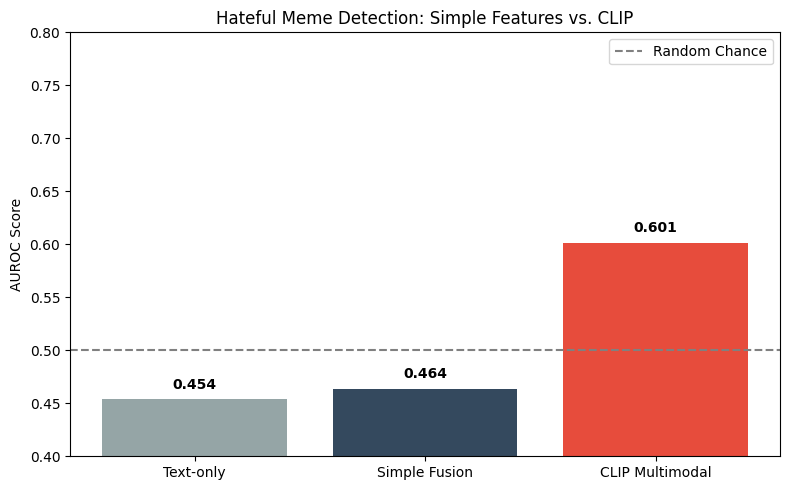

In [10]:
import os, sys, json, io, time, warnings
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import requests

warnings.filterwarnings("ignore")

# Curation note: external Hateful Memes acquisition, image downloads, and local cache creation are omitted.
# Provide separately licensed in-memory records before reproducing this experiment.

from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

train_texts = [d["text"] for d in train_subset]
val_texts   = [d["text"] for d in val_subset]
y_train     = np.array([d["label"] for d in train_subset])
y_val       = np.array([d["label"] for d in val_subset])

tfidf = TfidfVectorizer(max_features=1000, stop_words='english')
X_train_text = tfidf.fit_transform(train_texts)
X_val_text   = tfidf.transform(val_texts)

def get_color_hist(path):
    try:
        img = Image.open(path).convert("RGB").resize((64, 64))
        arr = np.array(img) / 255.0
        feats = []
        for i in range(3):
            hist, _ = np.histogram(arr[:,:,i], bins=8, range=(0,1))
            feats.extend(hist / hist.sum())
        return feats
    except: return np.zeros(24)

X_train_img = np.array([get_color_hist(d["img_path"]) for d in train_subset])
X_val_img   = np.array([get_color_hist(d["img_path"]) for d in val_subset])

X_train_fuse = hstack([X_train_text, csr_matrix(X_train_img)])
X_val_fuse   = hstack([X_val_text,   csr_matrix(X_val_img)])

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler

results = {}

def train_eval(name, X_tr, X_va):
    scaler = StandardScaler(with_mean=False)
    X_tr_s = scaler.fit_transform(X_tr)
    X_va_s = scaler.transform(X_va)
    
    clf = LogisticRegression(max_iter=500, random_state=42)
    clf.fit(X_tr_s, y_train)
    
    probs = clf.predict_proba(X_va_s)[:, 1]
    preds = clf.predict(X_va_s)
    auc = roc_auc_score(y_val, probs)
    return {"AUROC": auc, "probs": probs}

results["Text-only"]     = train_eval("Text-only (TF-IDF)", X_train_text, X_val_text)
results["Simple Fusion"] = train_eval("Fusion (TF-IDF + Color)", X_train_fuse, X_val_fuse)

import torch
from transformers import CLIPProcessor, CLIPModel

model_name = "openai/clip-vit-base-patch32"
# Curation note: pretrained-model loading is omitted from this static portfolio copy.

def get_clip_embeddings(subset):
    img_embs, txt_embs = [], []
    for i in range(0, len(subset), 32):
        batch = subset[i:i+32]
        images = [Image.open(d["img_path"]).convert("RGB") for d in batch]
        texts  = [d["text"] for d in batch]
        
        with torch.no_grad():
            inputs = clip_proc(text=texts, images=images, return_tensors="pt", padding=True, truncation=True)
            out = clip_model(**inputs)
            img_embs.append(out.image_embeds.numpy())
            txt_embs.append(out.text_embeds.numpy())
            
    return np.vstack(img_embs), np.vstack(txt_embs)

tr_img_emb, tr_txt_emb = get_clip_embeddings(train_subset)
va_img_emb, va_txt_emb = get_clip_embeddings(val_subset)

X_train_clip = np.hstack([tr_img_emb, tr_txt_emb])
X_val_clip   = np.hstack([va_img_emb, va_txt_emb])

clip_res = train_eval("CLIP Multimodal", X_train_clip, X_val_clip)
results["CLIP Multimodal"] = clip_res

import matplotlib.pyplot as plt

names = ["Text-only", "Simple Fusion", "CLIP Multimodal"]
aucs  = [results[n]["AUROC"] for n in names]
colors = ["#95a5a6", "#34495e", "#e74c3c"]

plt.figure(figsize=(8, 5))
bars = plt.bar(names, aucs, color=colors)
plt.ylim(0.4, 0.8)
plt.axhline(0.5, color='gray', linestyle='--', label='Random Chance')
plt.ylabel("AUROC Score")
plt.title("Hateful Meme Detection: Simple Features vs. CLIP")

for bar, v in zip(bars, aucs):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')

plt.legend()
plt.tight_layout()
out_path = os.path.join(FIGURES_DIR, "fig_bonus_comparison_simplified.png")
plt.show()

(5 pts)

Now, let's take some time to reflect. We have dug deep into the data collection and process portion of machine learning. Take some time to discuss:

1. The most interesting topic discussed in this homework assignment.
2. A challenging aspect that you did not expect to deal with and what insights you used to address it.
3. How you feel about the overall quality of your dataset? Is there anything lacking? What is particularly great about it?

There is no specific right answer we are looking for, answer how you think!